# Практическое задание 3: решение уравнений в частных производных с помощью DeepOKAN

## Нейродиффуры 2025

### ФИО: <впишите>

## Введение
В этом задании вы изучите работу сетей Колмогорова-Арнольда, получите практические навыки обучения нейронных операторов типа DeepONet, а также научитесь генерировать обучающие данные для решения дифференциальных уравнений с помощью нейронных операторов.

### Используемые библиотеки:
- [PyTorch](https://pytorch.org/) — инструмент для работы с нейронными сетями.
- [TensorBoard](https://www.tensorflow.org/tensorboard?hl=ru) — инструмент для логирования и визуализации.
- [NumPy](https://numpy.org/) — библиотека для научных вычислений.
- [tqdm](https://tqdm.github.io/) — инструмент для отображения прогресса.
- [Matplotlib](https://matplotlib.org/) — библиотека для визуализации.

In [1]:
import os
import random
from collections.abc import Callable
import math

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, default_collate
from torch.utils.tensorboard import SummaryWriter

import numpy as np

from tqdm.notebook import tqdm

from matplotlib import pyplot as plt

Зафиксируйте сиды, чтобы сделать свои эксперименты [воспроизводимыми](https://pytorch.org/docs/stable/notes/randomness.html).

In [2]:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    # Ensure deterministic behavior for cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Часть 1. Генерация данных для обучения
В этой части задания вы научитесь генерировать данные для обучения нейронных операторов. Предлагается решать начально-краевую задачу для одномерного [уравнения Бюргерса](https://en.wikipedia.org/wiki/Burgers%27_equation)
$$
    \frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial ^2u}{\partial x^2}
$$
в области $[0, 1] \times [0, 1]$ с нулевыми граничными условиями
$$
    u(0, t) = u(1, t) = 0, ~t \in [0, 1],
$$
и начальным условием
$$
    u(x, 0) = u_{0}, ~x \in [0, 1].
$$

В данном задании коэффициент вязкости $\nu$ фиксирован и задаёт семейство начально-краевых задач, различающихся только начальным условием $u_{0}$; оно и будет поступать на вход нейронному оператору. Помимо начального условия DeepONet, речь о котором пойдёт ниже, будет принимать на вход точку, в которой требуется вычислить значение функции $u$, являющейся решением задачи. В нашем случае эта точка задаётся парой $(x,~t) \in [0, 1] \times [0, 1]$.

Реализуйте класс [`BurgersDataset`](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html), задающий выборку из четвёрок вида $(x,~t,~u_{0},~u(x, t))$ на равномерной сетке $(X_{N},~T_{M})$, где $X_{N} = \{x_{i}\}_{i = 1}^{N}$, $T_{M} = \{t_{i}\}_{i = 1}^{M}$. Для этого:
1. Сгенерируйте случайные функции, определяющие начальные условия $u_{0}$.
2. Вычислите значения каждой из функций $u_{0}$ на сетке $X_{N}$.
3. Для каждого начального условия получите решение $u(x, t)$ уравнения на сетке $(X_{N},~T_{M})$, пользуясь каким-нибудь численным методом.
4. Включите в выборку лишь случайное подмножество полученных четвёрок. Это **важно** для избежания переобучения.

### Генерация начальных условий
Для создания обучающей выборки вам потребуется множество функций, задающих начальные условия. Существуют различные способы генерации функций; в данном задании для этого предлагается использовать [гауссовский случайный процесс](https://d2l.ai/chapter_gaussian-processes/gp-priors.html). Поскольку наш курс не посвящён случайным процессам, соответствующий метод уже реализован за вас (см. метод `_generate_fn`).

### Численное решение начально-краевой задачи
Чтобы получить референсные значения решения начально-краевой задачи, можно использовать [метод конечных разностей](https://en.wikipedia.org/wiki/Finite_difference_method). В этом методе производные, входящие в уравнение, аппроксимируются на заданной сетке конечными разностями. Для рассматриваемого уравнения Бюргерса можно выписать явную разностную схему первого порядка аппроксимации
$$
    \frac{u^{n+1}_{i} - u^{n}_{i}}{\Delta t} + u_{i}^{n} \frac{u^{n}_{i} - u^{n}_{i-1}}{\Delta x} =
        \nu \frac{u^{n}_{i+1} -2u^{n}_{i} + u^{n}_{i-1}}{\Delta x^{2}}.
$$

Поскольку начальное условие известно, эту разностную схему можно переписать в виде явного итерационного процесса
$$
    u^{n+1}_{i} = u^{n}_{i} - u^{n}_{i} \frac{\Delta t}{\Delta x} (u^{n}_{i} - u^{n}_{i-1}) +
        \frac{\nu \Delta t}{\Delta x^{2}}(u^{n}_{i+1} - 2u^{n}_{i} + u^{n}_{i-1}),
$$
который легко реализуется.

**Обратите внимание:** по умолчанию NumPy использует [массивы чисел](https://numpy.org/doc/stable/reference/arrays.html) двойной точности, т.е. типа `np.float64`. Для обучения нам потребуется лишь одинарная точность, поэтому не забывайте указывать явно соответствующий [тип данных](https://numpy.org/doc/stable/reference/arrays.dtypes.html) при создании массивов.

In [6]:
class BurgersDataset(Dataset):
    """
    A dataset with the numerical solution of the viscous 1D Burgers equation
    with zero boundary conditions and initial condition sampled from a Gaussian random field.
    """
    def __init__(
        self,
        n_functions: int = 150,
        nu: float = 0.01 / np.pi,
        x_l: float = 0.0,
        x_r: float = 1.0,
        dx: float = 0.01,
        t_max: float = 1.0,
        dt: float = 0.01,
        length_scale: float = 0.1,
        output_scale: float = 0.05,
        jitter: float = 1e-10,
        gp_n: int = 512,
        dropout_prob: float = 0.2,
        verbose: bool = False,
        subsample_step: int = 1
    ) -> None:
        """
        Args:
            n_functions (`int`): The number of functions to sample.

            nu (`float`): The coefficitent of viscosity.
            x_l (`float`): The left spatial boundary.
            x_r (`float`): The right spatial boundary.
            dx (`float`): The spatial step size.
            t_max (`float`): The right temporal boundary (left is assumed to be 0).
            dt (`float`): The temporal step size.

            length_scale (`float`): The length scale of the generated functions.
            output_scale (`float`): The output scale of the generated functions.
            jitter (`float`): The magnitude of the additive random jitter used in the Cholesky decomposition.
            gp_n (`int`): The size of the GP grid.

            dropout_prob (`float`): The probability of a data point being removed from the dataset.

            verbose (`bool`): Whether to display the progress bar during generation.
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        self.n_functions = n_functions
        self.nu = nu
        self.x_l = x_l
        self.x_r = x_r
        self.dx = dx
        self.t_max = t_max
        self.dt = dt
        self.subsample_step = subsample_step
        self.length_scale = length_scale
        self.output_scale = output_scale
        self.jitter = jitter
        self.gp_n = gp_n
        self.dropout_prob = dropout_prob
        self.verbose = verbose


        self.x_grid = np.arange(x_l, x_r + dx/2, dx, dtype=np.float32)
        self.t_grid = np.arange(0, t_max + dt/2, dt, dtype=np.float32)
        self.n_x = len(self.x_grid)
        self.n_t = len(self.t_grid)

        self.data = self._generate_data()

    def _solve_burgers(self, u_0_fn: Callable) -> np.ndarray:
        """
        Solves the Burgers equation given the initial condition 'u_0_fn'.

        Args:
            u_0_fn (`Callable`): A function describing the initial condition at each grid point.

        Returns:
            `np.ndarray`: A NumPy array of the shape ('n_x', 'n_t') containing the solution.
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        u = np.zeros((self.n_x, self.n_t), dtype=np.float32)

        u[:, 0] = u_0_fn(self.x_grid)
        u[0, 0] = 0.0
        u[-1, 0] = 0.0


        CLIP_AMP = 5.0

        for n in range(self.n_t - 1):
            for i in range(1, self.n_x - 1):
                u_next = u[i, n] - u[i, n] * (self.dt / self.dx) * (u[i, n] - u[i-1, n]) + \
                         (self.nu * self.dt / (self.dx**2)) * (u[i+1, n] - 2*u[i, n] + u[i-1, n]) # <-- Citation removed here

                u[i, n+1] = np.clip(u_next, -CLIP_AMP, CLIP_AMP)

            u[0, n+1] = 0.0
            u[-1, n+1] = 0.0

        return u

    def _generate_fn(self) -> Callable:
        """
        Generates a random function from a Gaussian random field.

        Returns:
            `Callable`: A random function which can be evaluated at any grid point.
        """
        # radial-basis function kernel
        def RBF(
            x1: np.ndarray,
            x2: np.ndarray,
            length_scale: float,
            output_scale: float
        ) -> np.ndarray:
            diffs = np.expand_dims(x1 / length_scale, 1) - \
                    np.expand_dims(x2 / length_scale, 0)
            r2 = np.sum(diffs**2, axis=2)
            return output_scale * np.exp(-0.5 * r2)

        x_l = self.x_l
        x_r = self.x_r

        length_scale = self.length_scale
        output_scale = self.output_scale
        jitter = self.jitter
        gp_n = self.gp_n

        X = np.linspace(x_l, x_r, gp_n)[:, None]
        K = RBF(X, X, length_scale, output_scale)
        L = np.linalg.cholesky(K + jitter*np.eye(gp_n))
        gp_sample = np.dot(L, np.random.normal(size=(gp_n,)))

        fn = lambda x: np.interp(x, X.flatten(), gp_sample)

        return fn

    def _generate_sample(self) -> np.ndarray:
        """
        Generates a single solution of the Burgers equation with a random initial condition.

        Returns:
            `np.ndarray`: A NumPy array of the shape ('n_x', 'n_t') containing the solution.
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        u_0_fn = self._generate_fn()
        solution = self._solve_burgers(u_0_fn)
        u0 = solution[:, 0]
        return u0, solution

    def _generate_data(self) -> np.ndarray:
        """
        Generates 'n_functions' solutions of the Burgers equation with random initial conditions.

        Returns:
            `np.ndarray`: A NumPy array of the shape ('n_functions', 'n_x', 'n_t') containing the solutions.
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        all_samples = []

        iterator = range(self.n_functions)
        if self.verbose:
            iterator = tqdm(iterator, desc="Generating dataset")

        for _ in iterator:
            u0, solution = self._generate_sample()

            xx, tt = np.meshgrid(self.x_grid, self.t_grid, indexing='ij')

            x_flat = xx.flatten()
            t_flat = tt.flatten()
            u_flat = solution.flatten()

            # for i in range(len(x_flat)):
            #     if random.random() < self.dropout_prob:
            #         continue

            #     xt = np.array([x_flat[i], t_flat[i]], dtype=np.float32)
            #     u_xt = np.array([u_flat[i]], dtype=np.float32)
            #     all_samples.append((xt, u0.copy(), u_xt))
            for i in range(0, len(x_flat), self.subsample_step):
                xt   = np.array([x_flat[i], t_flat[i]], dtype=np.float32)
                u_xt = np.array([u_flat[i]],       dtype=np.float32)
                all_samples.append((xt, u0.copy(), u_xt))


        return all_samples

    def __len__(self) -> int:
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        return len(self.data)

    def __getitem__(self, idx: int) -> tuple[np.ndarray, ...]:
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        return self.data[idx]

Далее необходимо создать пайплайн для обучения модели. Реализуйте [коллатор](https://pytorch.org/docs/stable/data.html#working-with-collate-fn) для сборки данных в батч. Вам может пригодиться функция [`torch.utils.data.default_collate`](https://pytorch.org/docs/stable/data.html#torch.utils.data.default_collate). Коллатор должен возвращать тройку тензоров следующих размерностей:
- $(x,~t)$: (`batch_size` $\times$ $2$);
- $u_{0}$: (`batch_size` $\times$ $N$);
- $u(x,~t)$: (`batch_size` $\times$ $1$).

In [7]:
def collate_fn(batch: tuple[np.ndarray, ...]) -> tuple[torch.Tensor, ...]:
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################

    collated_batch = default_collate(batch)


    return collated_batch

Создайте обучающий и валидационный датасеты, а также соответствующие [даталоадеры](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#preparing-your-data-for-training-with-dataloaders). Используйте сетку размера $N = M = 100$. Чтобы не допустить переобучения, при создании обучающей выборки рекомендуется сгенерировать большое число функций (например, 1000) и отбросить значительную часть полученных точек (например, 80%).

Определите размер батча, который поместится в память вашего устройства. Не забудьте перемешать обучающие данные в даталоадере.

**Обратите внимание:** не стоит перемешивать или отбрасывать точки, входящие в валидационную выборку. Данные в правильном порядке понадобятся вам позднее для визуализации и сравнения численного решения с предсказаниями модели.

In [8]:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################

# Common parameters
N_GRID = 101
DX = 0.01
DT = 0.001
NU = 0.01 / np.pi

N_FUNCTIONS_TRAIN = 1000
DROPOUT_TRAIN = 0.80

N_FUNCTIONS_VAL = 50
DROPOUT_VAL = 0.0

BATCH_SIZE = 2048

LENGTH_SCALE = 0.1
OUTPUT_SCALE = 0.05
JITTER = 1e-10
GP_N = 512

print("Generating training dataset...")
train_dataset = BurgersDataset(
    n_functions=N_FUNCTIONS_TRAIN,
    nu=NU,
    dx=DX,
    dt=DT,
    length_scale=LENGTH_SCALE,
    output_scale=OUTPUT_SCALE,
    jitter=JITTER,
    gp_n=GP_N,
    dropout_prob=DROPOUT_TRAIN,
    verbose=True,
    subsample_step=10,
)
print(f"Training dataset size: {len(train_dataset)}")

print("\nGenerating validation dataset...")
val_dataset = BurgersDataset(
    n_functions=N_FUNCTIONS_VAL,
    nu=NU,
    dx=DX,
    dt=DT,
    length_scale=LENGTH_SCALE,
    output_scale=OUTPUT_SCALE,
    jitter=JITTER,
    gp_n=GP_N,
    dropout_prob=DROPOUT_VAL,
    verbose=True,
    subsample_step=10,
)
print(f"Validation dataset size: {len(val_dataset)}")

N_X = val_dataset.n_x
N_T = val_dataset.n_t # N_T will now be 1001
print(f"Grid size: Nx={N_X}, Nt={N_T}")

Generating training dataset...


Generating dataset:   0%|          | 0/1000 [00:00<?, ?it/s]

Training dataset size: 10111000

Generating validation dataset...


Generating dataset:   0%|          | 0/50 [00:00<?, ?it/s]

Validation dataset size: 505550
Grid size: Nx=101, Nt=1001


## Часть 2. Реализация сети Колмогорова-Арнольда
Во второй части задания предлагается самостоятельно реализовать сеть Колмогорова-Арнольда (KAN).

Идея, лежащая в основе KAN, вдохновлена следующей теоремой.

**Теорема 1** ***(теорема Колмогорова-Арнольда)***. Непрерывная функция многих переменных $f: [0,~1]^{n} \rightarrow \mathbb{R}$ может быть представлена в виде конечной суперпозиции непрерывных функций одной переменной и бинарной операции сложения:
$$
    f(\mathbf{x}) = f(x_{1}, ~\ldots, ~x_{n}) = \sum_{q = 1}^{2n + 1} \Phi_{q} \left( \sum_{p = 1}^{n} \phi_{q, p}(x_{p}) \right).
$$

Конкретно, строится нейронная сеть, в которой обучаемые параметры переносятся с вершин графа вычислений на его рёбра, т.е. в функции активации, и, таким образом, процесс обучения состоит в подборе функций, аппроксимирующих исходную зависимость.

Слой KAN с $n_{\text{in}}$-мерным входом и $n_{\text{out}}$-мерным выходом может быть представлен в виде функциональной матрицы, составленной из функций одной переменной
$$
    \boldsymbol{\Phi} = \{\phi_{q, p}\}, ~p \in [1, ~n_{\text{in}}], ~q \in [1, ~n_{\text{out}}],
$$
где каждая из функций $\phi_{q, p}$ имеет обучаемые параметры. Значение $j$-го нейрона на $(l + 1)$-м слое определяется как сумма
$$
    x_{j}^{(l + 1)} = \sum_{i = 1}^{n_{l}} \phi_{j, i}^{(l)}(x_{i}^{(l)}), ~j \in [1, ~n_{l + 1}],
$$
или, в матричной форме,
$$
    \mathbf{x}^{(l + 1)} =
    \begin{pmatrix}
        \phi_{1, 1}^{(l)}(\cdot)         & \phi_{1, 2}^{(l)}(\cdot)         & \cdots & \phi_{1, n_{l}}^{(l)}(\cdot)         \\
        \phi_{2, 1}^{(l)}(\cdot)         & \phi_{2, 2}^{(l)}(\cdot)         & \cdots & \phi_{2, n_{l}}^{(l)}(\cdot)         \\
        \vdots                           & \vdots                           &        & \vdots                               \\
        \phi_{n_{l + 1}, 1}^{(l)}(\cdot) & \phi_{n_{l + 1}, 2}^{(l)}(\cdot) & \cdots & \phi_{n_{l + 1}, n_{l}}^{(l)}(\cdot)
    \end{pmatrix} \mathbf{x}^{(l)}.
$$

При этом KAN определяется как композиция $L$ слоёв:
$$
    \text{KAN}(\mathbf{x}) = (\boldsymbol{\Phi}_{L - 1} \circ \boldsymbol{\Phi}_{L - 2} \circ \ldots \circ
        \boldsymbol{\Phi}_{1} \circ \boldsymbol{\Phi}_{0}) \mathbf{x}.
$$
В частности, представление из теоремы Колмогорова-Арнольда можно рассматривать как двухслойную KAN: внутренние функции формируют слой с $n_{\text{in}} = n$, $n_{\text{out}} = 2n + 1$, а внешние — с $n_{\text{in}} = 2n + 1$, $n_{\text{out}} = 1$.

В оригинальной статье [2] (см. [официальную реализацию](https://github.com/KindXiaoming/pykan)) авторы параметризуют функции активации как взвешенную сумму линейной комбинации [B-сплайнов](https://en.wikipedia.org/wiki/B-spline) $B_{i}$ с обучаемыми коэффициентами $c_{i}$ и нелинейной функции активации [SiLU](https://pytorch.org/docs/stable/generated/torch.nn.SiLU.html):
$$
    \phi(x) = w_{s} \text{spline}(x) + w_{b} b(x),
$$
где
$$
    \text{spline}(x) = \sum_{i} c_{i} B_{i}(x),
$$
$$
    b(x) = \text{SiLU}(x) = \frac{x}{1 + e^{-x}},
$$
и $w_{s}$, $w_{b}$ — обучаемые веса. Поскольку реализация такой модели сопряжена с определёнными сложностями, в данном задании предлагается использовать более простые базисные функции.

Реализуйте сеть Колмогорова-Арнольда в классах `KANLayer` и `KAN` с базисными функциями, соответствующими вашему варианту задания.

In [9]:
# --- Hermite Function Implementation (Variant 3) ---
_FACTORIALS = [math.factorial(i) for i in range(20)]
_SQRT_2PI_INV = 1.0 / math.sqrt(2.0 * math.pi)


def get_factorial(k):
    if k < len(_FACTORIALS):
        return _FACTORIALS[k]
    else:
        res = _FACTORIALS[-1]
        for i in range(len(_FACTORIALS), k + 1):
            res *= i
        return res

def hermite_polynomials(x: torch.Tensor, k_max: int) -> torch.Tensor:
    """Computes Hermite polynomials H_k(x) up to order k_max, avoiding inplace ops."""
    if k_max < 0:
        return torch.empty(*x.shape, 0, device=x.device, dtype=x.dtype)

    H_list = []
    h0 = torch.ones_like(x)
    H_list.append(h0)

    if k_max == 0:
         return torch.stack(H_list, dim=-1)

    h1 = 2.0 * x
    H_list.append(h1)

    if k_max == 1:
        return torch.stack(H_list, dim=-1)

    hk_minus_2 = h0
    hk_minus_1 = h1

    for k in range(2, k_max + 1):
        hk = 2.0 * x * hk_minus_1 - 2.0 * (k - 1) * hk_minus_2
        H_list.append(hk)
        hk_minus_2 = hk_minus_1
        hk_minus_1 = hk

    H = torch.stack(H_list, dim=-1)
    return H

def hermite_functions(x: torch.Tensor, basis_size: int) -> torch.Tensor:
    # 将输入映射到 [-sqrt(2*basis_size+1), sqrt(2*basis_size+1)]
    mapped_x = torch.tanh(x) * math.sqrt(2 * basis_size + 1)

    k_max = basis_size - 1
    if k_max < 0:
        return torch.empty(*x.shape, 0, device=x.device, dtype=x.dtype)

    Hk = hermite_polynomials(mapped_x, k_max)

    # 计算 ϕ(x) = (1/√(2π)) * exp(-x²/2)
    phi = _SQRT_2PI_INV * torch.exp(-0.5 * mapped_x**2)
    phi = phi.unsqueeze(-1)  # 保持形状 (*x.shape, 1)

    # 正确计算归一化系数 α_k = 1/(sqrt(2^k * k!) * π^(1/4))
    alpha = torch.zeros(basis_size, device=x.device, dtype=x.dtype)
    for k in range(basis_size):
        fact_k = get_factorial(k)
        pow2_k = 2.0**k
        denom = math.sqrt(pow2_k * fact_k) * (math.pi ** 0.25)
        alpha[k] = 1.0 / (denom + 1e-12)

    # 调整alpha的形状以便广播
    alpha = alpha.view(*(1,) * x.dim(), basis_size)

    hk = alpha * Hk * phi
    return hk


In [10]:
class KANLayer(nn.Module):
    """
    A single Kolmogorov-Arnold layer.
    """
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    def __init__(self, in_features: int, out_features: int, basis_size: int):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.basis_size = basis_size

        self.weights = nn.Parameter(torch.empty(out_features, in_features, basis_size))
        nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))

        self.basis_function = lambda x: hermite_functions(x, self.basis_size)



    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (`torch.Tensor`): Input tensor of shape (batch_size, in_features).
        Returns:
            `torch.Tensor`: Output tensor of shape (batch_size, out_features).
        """
        batch_size = x.shape[0]


        basis_eval = self.basis_function(x)

        output = torch.einsum('bik,oik->bo', basis_eval, self.weights)

        return output


class KAN(nn.Module):
    """
    The Kolmogorov-Arnold network.
    """
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    def __init__(self, layers: list[int], basis_size: int):
        """
        Args:
            layers (list[int]): List of layer dimensions, e.g., [input_dim, hidden1_dim, ..., output_dim].
            basis_size (int): The number of basis functions (m) for each activation.
        """
        super().__init__()
        self.layers = nn.ModuleList()
        self.layer_dims = layers
        self.basis_size = basis_size

        if len(layers) < 2:
            raise ValueError("KAN must have at least an input and an output layer.")

        for i in range(len(layers) - 1):
            in_dim = layers[i]
            out_dim = layers[i+1]
            self.layers.append(KANLayer(in_dim, out_dim, basis_size))




    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the KAN network.
        Args:
            x (`torch.Tensor`): Input tensor of shape (batch_size, layers[0]).
        Returns:
            `torch.Tensor`: Output tensor of shape (batch_size, layers[-1]).
        """
        for layer in self.layers:
            x = layer(x)
        return x

## Часть 3. Реализация нейронного оператора

Третья часть задания посвящена реализации нейронного оператора DeepONet [2]. Вспомним универсальную теорему аппроксимации для операторов.

**Теорема 2** ***(универсальная теорема аппроксимации для операторов).***
Пусть $\sigma$ — непрерывная неполиномиальная функция, $X$ — банахово пространство, $K_{1} \subset X$, $K_{2} \subset \mathbb{R}^{d}$ — пара компактных множеств в $X$ и $\mathbb{R}^{d}$ соответственно, $V$ — компактное множество в $C(K_{1})$, и $G$ — нелинейный непрерывный оператор, отображающий $V$ в $C(K_{2})$. Тогда $\forall \varepsilon > 0 ~\exists ~n, ~p, ~m \in \mathbb{Z}^{+}, ~c_{i}^{(k)}, ~\xi_{ij}^{(k)}, ~\theta_{i}^{(k)}, ~\zeta^{(k)} \in \mathbb{R}, ~w^{(k)} \in \mathbb{R}^{d}, ~x_{j} \in K_{1}, ~i \in [1,~n], ~k \in [1,~p], ~j \in [1,~m]$, такие, что неравенство
$$
	\left|G(u)(y) - \sum_{k = 1}^{p}
	\underbrace{\sum_{i = 1}^{n} c_{i}^{(k)}\sigma\left(\sum_{j = 1}^{m}\xi_{ij}^{(k)}u(x_j) + \theta_{i}^{(k)}\right)}_{\text{``ветвь''}}
	\underbrace{\sigma\left(\left\langle w^{(k)}, y \right\rangle + \zeta^{(k)}\right)}_{\text{``магистраль''}}\right| < \varepsilon
$$
выполняется сразу для всех $u \in V$, $y \in K_{2}$.

Непосредственно из теоремы 2 вытекает структура DeepONet. В самом деле, обозначив через $b(u) \in \mathbb{R}^{p}$, $t(y) \in \mathbb{R}^{p}$ ветвь и магистальную сеть соответственно, получим аппроксимацию исходного оператора
$$
    G(u)(y) \approx \sum_{k = 1}^{p} b_{k}(u)t_{k}(y) = \langle b(u), t(y) \rangle.
$$

На практике архитектуры сетей $b(u)$, $t(y)$ могут быть выбраны произвольно, в частности, в их качестве можно использовать сети Колмогорова-Арнольда. Обычно к скалярному произведению прибавляют также обучаемый [параметр](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html) смещения $b_{0}$:
$$
    G(u)(y) \approx \langle b(u), t(y) \rangle + b_{0}.
$$

Реализуйте описанную аппроксимацию в классе `DeepONet`.

In [11]:
class DeepONet(nn.Module):
    """
    The DeepONet neural operator.
    """
    def __init__(
        self,
        branch_net: type(nn.Module),
        branch_config: dict,
        trunk_net: type(nn.Module),
        trunk_config: dict,
        output_bias: bool = True
    ) -> None:
        """
        Args:
            branch_net (`nn.Module`): A class implementing the "branch" network.
            branch_config (`dict`): A dictionary with branch_net's parameters.

            trunk_net (`nn.Module`): A class implementing the "trunk" network.
            trunk_config (`dict`): A dictionary with trunk_net's parameters.

            output_bias (`bool`): Whether to add a trainable bias to the output.
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        super().__init__()

        self.branch = branch_net(**branch_config)
        self.trunk = trunk_net(**trunk_config)

        branch_output_dim = self.branch.layer_dims[-1]
        trunk_output_dim = self.trunk.layer_dims[-1]
        if branch_output_dim != trunk_output_dim:
            raise ValueError(
                f"Output dimensions of branch ({branch_output_dim}) "
                f"and trunk ({trunk_output_dim}) must match."
            )

        self.use_bias = output_bias
        if self.use_bias:
            # Initialize bias to zero
            self.bias = nn.Parameter(torch.zeros(1))

    def forward(
        self,
        x_func: torch.Tensor,
        x_loc: torch.Tensor
    ) -> torch.Tensor:
        """
        Performs a forward pass.

        Args:
            x_func (`torch.Tensor`): The branch's input.
            x_loc (`torch.Tensor`): The trunk's input.

        Returns:
            `torch.Tensor`: The result of the forward pass.
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        branch_output = self.branch(x_func)
        trunk_output = self.trunk(x_loc)


        output = torch.sum(branch_output * trunk_output, dim=-1, keepdim=True) # Shape: (batch_size, 1)

        if self.use_bias:
            output = output + self.bias

        return output

## Часть 4. Обучение модели

Последняя часть задания — обучение полученной операторной сети на сгенерированных данных. Реализуйте пайплайн обучения в классе `BurgersTrainer`, используя предложенный шаблон. Залогируйте с помощью [`SummaryWriter`](https://pytorch.org/docs/stable/tensorboard.html) две величины:
1. Значение функции потерь для каждого батча при обучении (`loss/train`).
2. Значение функции потерь на валидации для каждой эпохи (`loss/eval`).

Не забудьте при вычислении лосса на валидации перевести модель в режим инференса и воспользоваться контекстным менеджером [`torch.no_grad`](https://pytorch.org/docs/stable/generated/torch.no_grad.html).

In [12]:
class BurgersTrainer:
    """
    A trainer class for the data described by the class 'BurgersDataset'.
    """
    def __init__(
        self,
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        criterion: nn.Module,
        scheduler: torch.optim.lr_scheduler.LRScheduler = None,
        logdir: str = None,
        device: str = None
    ) -> None:
        """
        Args:
            model (`nn.Module`): A DeepONet model.
            optimizer (`torch.optim.Optimizer`): An optimizer.
            criterion (`nn.Module`): An optimization criterion.
            scheduler (`torch.optim.lr_scheduler.LRScheduler`): A learning rate scheduler.

            logdir (`str`): The directory for the 'SummaryWriter' to write logs to.
            device (`str`): The device on which tensor operations are to be executed ("cpu" or "cuda").
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.logdir = logdir

        if device is None:
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
        else:
            self.device = device

        print(f"Using device: {self.device}")

        self.model.to(self.device)

        self.writer = SummaryWriter(log_dir=self.logdir)

        self.global_train_step = 0

    def _calculate_loss(self, batch: tuple[torch.Tensor, ...]) -> torch.Tensor:
        """
        Calculates the criterion value for the given batch.

        Args:
            batch (`tuple[torch.Tensor, ...]`): A batch containing the tensors ('xt', 'u_0', 'u_xt'), where
                xt has the shape ('batch_size', 2),
                u_0 has the shape ('batch_size', 'n_x'),
                u_xt has the shape ('batch_size', 1).

        Returns:
            `torch.Tensor`: The criterion value for the given batch.
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        xt, u0, u_xt_target = batch

        xt = xt.to(self.device)
        u0 = u0.to(self.device)
        u_xt_target = u_xt_target.to(self.device)

        u_xt_pred = self.model(u0, xt)

        loss = self.criterion(u_xt_pred, u_xt_target)

        return loss

    def _train_step(self, dataloader: DataLoader) -> float:
        """
        Performs a single training pass through 'dataloader'.

        Args:
            dataloader (`DataLoader`): A dataloader for a dataset of the class 'BurgersDataset'.

        Returns:
            `float`: Average loss value across the samples from 'dataloader'.
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        self.model.train()
        total_loss = 0.0
        num_batches = len(dataloader)

        pbar = tqdm(dataloader, desc="Training", leave=False)
        for batch in pbar:
            self.optimizer.zero_grad()

            loss = self._calculate_loss(batch)

            loss.backward()

            self.optimizer.step()

            batch_loss = loss.item()
            self.writer.add_scalar('loss/train_batch', batch_loss, self.global_train_step)
            self.global_train_step += 1

            total_loss += batch_loss
            pbar.set_postfix({'batch_loss': f'{batch_loss:.4e}'})

        avg_loss = total_loss / num_batches
        return avg_loss

    def _eval_step(self, dataloader: DataLoader) -> float:
        """
        Performs a single validation pass through 'dataloader'.

        Args:
            dataloader (`DataLoader`): A dataloader for a dataset of the class 'BurgersDataset'.

        Returns:
            `float`: Average loss value across the samples from 'dataloader'.
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        self.model.eval()
        total_loss = 0.0
        num_batches = len(dataloader)

        with torch.no_grad():
            pbar = tqdm(dataloader, desc="Evaluating", leave=False)
            for batch in pbar:
                loss = self._calculate_loss(batch)
                total_loss += loss.item()

        avg_loss = total_loss / num_batches
        return avg_loss

    def train(
        self,
        dataloaders: dict,
        n_epochs: int,
        verbose: bool = False
    ) -> None:
        """
        Trains the model.

        Args:
            dataloaders (`dict`): A dictionary of the form
                {"train": 'train_dataloader', "eval": 'eval_dataloader'}, where
                'train_dataloader' is a dataloader with the training data,
                'eval_dataloader' is a dataloader with the validation data.
            n_epochs (`int`): The number of training epochs.
            verbose (`bool`): Whether to display the progress bar during training.
        """
        ###########################
        ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
        ###########################
        train_loader = dataloaders["train"]
        eval_loader = dataloaders["eval"]

        best_eval_loss = float('inf')

        iterator = range(n_epochs)
        if verbose:
           iterator = tqdm(iterator, desc="Epochs")

        for epoch in iterator:
            train_loss = self._train_step(train_loader)

            eval_loss = self._eval_step(eval_loader)

            self.writer.add_scalar('loss/train_epoch', train_loss, epoch)
            self.writer.add_scalar('loss/eval_epoch', eval_loss, epoch)

            # Log learning rate
            if self.scheduler:
                 self.writer.add_scalar('learning_rate', self.optimizer.param_groups[0]['lr'], epoch)

            if verbose:
                tqdm.write(f"Epoch {epoch+1}/{n_epochs} - "
                           f"Train Loss: {train_loss:.4e}, Eval Loss: {eval_loss:.4e}")

            if self.scheduler:
                if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step(eval_loss)
                else:
                    self.scheduler.step()

            if eval_loss < best_eval_loss:
                best_eval_loss = eval_loss


        # Close the TensorBoard writer
        self.writer.close()
        print("Training finished.")

Задайте конфигурацию своей операторной сети и инстанцируйте модель.

**Обратите внимание** на то, что в конфигурации KAN задаётся число *функций* на каждом скрытом слое, а не число *нейронов*. Не стоит делать вашу сеть слишком широкой.

In [15]:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
BASIS_SIZE = 10

BRANCH_LAYERS = [N_X, 128, 256, 128]
TRUNK_LAYERS = [2, 64, 128, 128]



if 'N_X' not in globals():
     raise NameError("N_X (grid size) is not defined. Make sure dataset generation ran.")

BRANCH_LAYERS[0] = N_X

branch_config = {"layers": BRANCH_LAYERS, "basis_size": BASIS_SIZE}
trunk_config = {"layers": TRUNK_LAYERS, "basis_size": BASIS_SIZE}

model = DeepONet(
    branch_net=KAN,
    branch_config=branch_config,
    trunk_net=KAN,
    trunk_config=trunk_config,
    output_bias=True
)

print("Model Configuration:")
print(f"  Basis Size (Hermite): {BASIS_SIZE}")
print(f"  Branch KAN Layers: {BRANCH_LAYERS}")
print(f"  Trunk KAN Layers: {TRUNK_LAYERS}")
print(model)

Model Configuration:
  Basis Size (Hermite): 10
  Branch KAN Layers: [101, 128, 256, 128]
  Trunk KAN Layers: [2, 64, 128, 128]
DeepONet(
  (branch): KAN(
    (layers): ModuleList(
      (0-2): 3 x KANLayer()
    )
  )
  (trunk): KAN(
    (layers): ModuleList(
      (0-2): 3 x KANLayer()
    )
  )
)


Посчитайте число *обучаемых* параметров в полученной модели.

Отметим, что, как правило, для решения рассматриваемой задачи достаточно небольшой сети, число параметров в которой не превосходит $10^{5}$.

In [16]:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params = count_parameters(model)
print(f"\nTotal number of trainable parameters: {num_params:,}")

if num_params > 500000:
    print("Warning: Model size might be larger than typically needed.")



Total number of trainable parameters: 1,031,681


Предлагается обучать модель минимизации функции потерь [MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html) на обучающей выборке. Задайте критерий и метод оптимизации, а также, при желании, планировщик скорости обучения, и инстанцируйте реализованный пайплайн.

Для этой части задания GPU даёт существенное ускорение, поэтому стоит по возможности делать обучение с большим размером батча и на GPU.

В оригинальной статье [1] приводятся примеры обучения с использованием [LBFGS](https://en.wikipedia.org/wiki/Limited-memory_BFGS). Не рекомендуется этим заниматься; используйте стохастический метод оптимизации, например, [Adam](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html).

In [17]:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
import torch.optim as optim

criterion = nn.MSELoss()

LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5

# 将 Adam 换成 AdamW
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=10, verbose=True)

LOG_DIR = "runs/burgers_deepokan_hermite"
trainer = BurgersTrainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    logdir=LOG_DIR,
)

print(f"\nTrainer initialized. Logs will be saved to: {LOG_DIR}")
print(f"Optimizer: Adamw, LR: {LEARNING_RATE}")
print(f"Criterion: MSELoss")
if scheduler:
    print(f"Scheduler: {type(scheduler).__name__}")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Using device: cuda

Trainer initialized. Logs will be saved to: runs/burgers_deepokan_hermite
Optimizer: Adamw, LR: 0.0001
Criterion: MSELoss
Scheduler: ReduceLROnPlateau


Наконец, задайте число эпох обучения и обучите модель.

**Обратите внимание:** для достижения хорошей точности не требуется обучать модель на протяжении большого числа эпох. В частности, при использовании выборки из $1000$ функций с отбрасыванием $80\%$ точек и с размером батча $2^{15}$ можно достичь точности на валидации порядка $10^{-4}$ менее чем за $100$ эпох.

Если у вас *не получается* достичь достаточной точности (MSE на валидации порядка хотя бы $10^{-3}$), попробуйте обучить DeepONet на основе MLP, чтобы убедиться в правильности реализации пайплайна и операторной сети.

In [18]:
# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created.")

DataLoaders created.


In [23]:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
N_EPOCHS = 100 # Adjust as needed based on convergence

print(f"\nStarting training for {N_EPOCHS} epochs...")

dataloaders = {"train": train_loader, "eval": val_loader}

trainer.train(dataloaders=dataloaders, n_epochs=N_EPOCHS, verbose=True)



Starting training for 100 epochs...


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/4938 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 1/100 - Train Loss: 1.2983e-02, Eval Loss: 2.4032e-02


...

Evaluating:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 99/100 - Train Loss: 5.1633e-03, Eval Loss: 2.3347e-02


Training:   0%|          | 0/4938 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/124 [00:00<?, ?it/s]

Epoch 100/100 - Train Loss: 5.1632e-03, Eval Loss: 2.3347e-02
Training finished.


Проверьте визуальное сходство предсказаний модели с численным решением. Для этого пересчитайте предсказания на произвольном примере из валидационной выборки (вспомним, что мы сохранили в этой выборке все точки сетки в правильном порядке).

In [24]:
###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
def get_predictions_for_sample(model, dataset, sample_index, device):
    """Gets model predictions for a specific function sample from the dataset."""
    model.eval() # Set model to evaluation mode


    points_per_function = dataset.n_x * dataset.n_t
    start_idx = sample_index * points_per_function
    end_idx = (sample_index + 1) * points_per_function

    if end_idx > len(dataset):
         raise IndexError(f"Sample index {sample_index} out of bounds "
                          f"for dataset with {len(dataset)} points "
                          f"({dataset.n_functions} functions assumed).")

    sample_data = [dataset[i] for i in range(start_idx, end_idx)]


    temp_loader = DataLoader(sample_data, batch_size=BATCH_SIZE*4, shuffle=False, collate_fn=collate_fn)

    predictions = []
    ground_truth = []
    coords_xt = []
    u0_func = None

    with torch.no_grad():
        for batch in temp_loader:
            xt, u0, u_xt_target = batch
            xt = xt.to(device)
            u0 = u0.to(device)

            u_xt_pred = model(u0, xt)

            predictions.append(u_xt_pred.cpu().numpy())
            ground_truth.append(u_xt_target.numpy())
            coords_xt.append(xt.cpu().numpy())

            # Store the initial condition (should be the same for the whole sample)
            if u0_func is None:
                u0_func = u0[0].cpu().numpy() # Store one instance

    predictions = np.concatenate(predictions, axis=0).flatten()
    ground_truth = np.concatenate(ground_truth, axis=0).flatten()
    coords_xt = np.concatenate(coords_xt, axis=0)

    pred_grid = predictions.reshape((dataset.n_x, dataset.n_t))
    gt_grid = ground_truth.reshape((dataset.n_x, dataset.n_t))

    return pred_grid, gt_grid, u0_func, dataset.x_grid, dataset.t_grid


In [25]:

SAMPLE_IDX_TO_PLOT = 0
if len(val_dataset) == 0:
     print("Validation dataset is empty, cannot plot.")
else:
    if val_dataset.dropout_prob != 0.0:
         print("Warning: Validation set has dropout applied. Plotting might be inaccurate.")
         print("Please regenerate validation set with dropout_prob=0.0 for correct visualization.")
    else:
        print(f"\nGenerating predictions for validation sample {SAMPLE_IDX_TO_PLOT}...")

        pred_solution, gt_solution, u0_initial, x_vals, t_vals = get_predictions_for_sample(
            model, val_dataset, SAMPLE_IDX_TO_PLOT, trainer.device
        )

        print("Predictions generated.")

        error_l2 = np.linalg.norm(pred_solution - gt_solution) / np.linalg.norm(gt_solution)
        print(f"Relative L2 error for sample {SAMPLE_IDX_TO_PLOT}: {error_l2:.4e}")
        mse = np.mean((pred_solution - gt_solution)**2)
        print(f"MSE for sample {SAMPLE_IDX_TO_PLOT}: {mse:.4e}")



Generating predictions for validation sample 0...
Predictions generated.
Relative L2 error for sample 0: 3.3940e-01
MSE for sample 0: 1.3370e-02


Осталось изобразить на графике предсказания вашей модели и сравнить с решением, полученным методом конечных разностей. Для этого можно использовать, например, функцию [`matplotlib.pyplot.pcolor`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pcolor.html).

Если вы наблюдаете очевидные *артефакты*, такие как полностью константное решение или константную диагональ, то могла быть допущена ошибка в реализации сети Колмогорова-Арнольда, например, применение layer-нормализации ко входу магистральной сети.

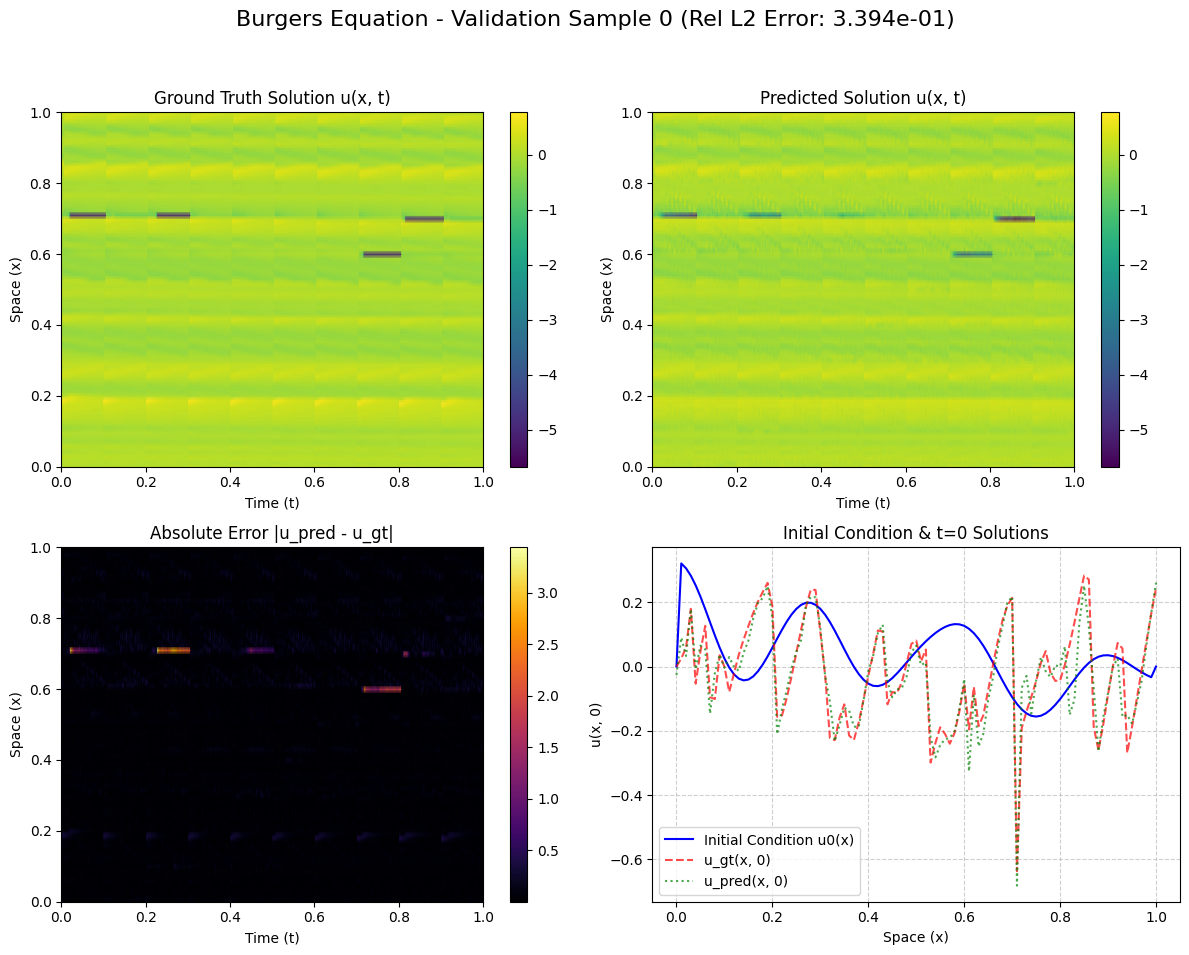

In [26]:
def plot(
    x: np.ndarray,
    t: np.ndarray,
    u_pred: np.ndarray,
    u_gt: np.ndarray,
    u0: np.ndarray,
    sample_idx: int,
    error: float
) -> None:
    """
    Plots the predicted and the ground truth solutions on the meshgrid ('x', 't')

    Args:
        x (`np.ndarray`): The spatial part of the meshgrid.
        t (`np.ndarray`): The temporal part of the meshgrid.
        u_pred (`np.ndarray`): The predicted solution.
        u_gt (`np.ndarray`): The ground truth solution.
    """
    ###########################
    ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    ###########################
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"Burgers Equation - Validation Sample {sample_idx} (Rel L2 Error: {error:.3e})", fontsize=16)

    vmin = min(np.min(u_gt), np.min(u_pred))
    vmax = max(np.max(u_gt), np.max(u_pred))

    im_gt = axes[0, 0].pcolormesh(t, x, u_gt, cmap='viridis', shading='gouraud', vmin=vmin, vmax=vmax)
    axes[0, 0].set_xlabel("Time (t)")
    axes[0, 0].set_ylabel("Space (x)")
    axes[0, 0].set_title("Ground Truth Solution u(x, t)")
    fig.colorbar(im_gt, ax=axes[0, 0])

    im_pred = axes[0, 1].pcolormesh(t, x, u_pred, cmap='viridis', shading='gouraud', vmin=vmin, vmax=vmax)
    axes[0, 1].set_xlabel("Time (t)")
    axes[0, 1].set_ylabel("Space (x)")
    axes[0, 1].set_title("Predicted Solution u(x, t)")
    fig.colorbar(im_pred, ax=axes[0, 1])

    error_map = np.abs(u_pred - u_gt)
    im_err = axes[1, 0].pcolormesh(t, x, error_map, cmap='inferno', shading='gouraud')
    axes[1, 0].set_xlabel("Time (t)")
    axes[1, 0].set_ylabel("Space (x)")
    axes[1, 0].set_title("Absolute Error |u_pred - u_gt|")
    fig.colorbar(im_err, ax=axes[1, 0])

    axes[1, 1].plot(x, u0, label='Initial Condition u0(x)', color='blue')
    axes[1, 1].plot(x, u_gt[:, 0], 'r--', label='u_gt(x, 0)', alpha=0.7)
    axes[1, 1].plot(x, u_pred[:, 0], 'g:', label='u_pred(x, 0)', alpha=0.7)
    axes[1, 1].set_xlabel("Space (x)")
    axes[1, 1].set_ylabel("u(x, 0)")
    axes[1, 1].set_title("Initial Condition & t=0 Solutions")
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

###########################
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
###########################
if 'pred_solution' in globals() and val_dataset.dropout_prob == 0.0:
    plot(
        x=x_vals,
        t=t_vals,
        u_pred=pred_solution,
        u_gt=gt_solution,
        u0=u0_initial,
        sample_idx=SAMPLE_IDX_TO_PLOT,
        error=error_l2
    )
elif val_dataset.dropout_prob != 0.0:
     print("\nSkipping final plot because validation set used dropout.")
else:
     print("\nSkipping final plot as predictions were not generated (e.g., empty validation set).")


In [27]:
%load_ext tensorboard
%tensorboard --logdir=runs/burgers_deepokan_hermite


<IPython.core.display.Javascript object>

In [28]:
# 在最后一个 Cell 里添加
from google.colab import runtime
runtime.unassign()  # 断开并删除当前运行时


Задание выполнено. Не забудьте прислать вместе с заполненным ноутбуком логи `TensorBoard`.

*Место для ваших выводов, комментариев, обратной связи (необязательно).*

## Литература
[1] Liu Z. et al. KAN: Kolmogorov-arnold networks // [arXiv preprint arXiv:2404.19756](https://arxiv.org/abs/2404.19756). – 2024.

[2] Lu L., Jin P., Karniadakis G. E.: DeepONet: Learning nonlinear operators for identifying differential equations based on the universal approximation theorem of operators // [arXiv preprint arXiv:1910.03193](https://arxiv.org/abs/1910.03193). – 2019.

[3] Abueidda D. W., Pantidis P., Mobasher M. E.: DeepOKAN: Deep Operator Network Based on Kolmogorov Arnold Networks for Mechanics Problems // [arXiv preprint arXiv:2405.19143](https://arxiv.org/abs/2405.19143). - 2024.